### model_training--User Return Prediction
I solved a problem for startup compony website. it will help alot to find out the user behavior. then compony esay to make the dicision . how to sale our product using user behaavior. and what kind of user visit in our website.

In [2]:
import seaborn as sns
import numpy as  np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.preprocessing import FunctionTransformer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer
from sklearn.model_selection import cross_validate



In [3]:
df = pd.read_csv("../data/gold/feature_data.csv")
df.head()

,Page Views,Session Duration,Traffic Source,Time on Page,Previous Visits,Return
0,5,11.051381,Organic,3.890460,3,1
1,4,3.429316,Social,8.478174,0,1
2,4,1.621052,Organic,9.636170,2,1
3,5,3.629279,Organic,2.071925,3,0
4,5,4.235843,Paid,1.960654,5,0


<Axes: xlabel='Time on Page', ylabel='Session Duration'>

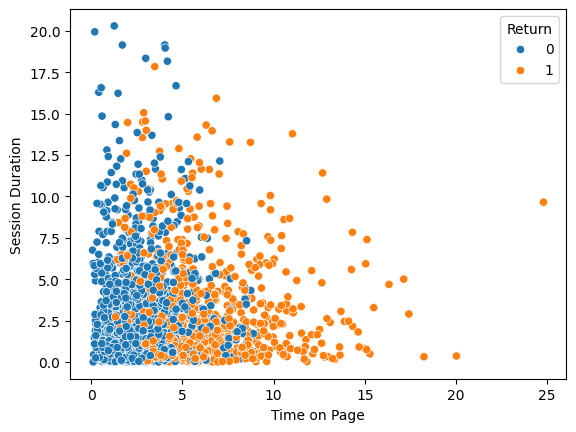

In [4]:
sns.scatterplot(x=df['Time on Page'], y=df['Session Duration'], hue=df['Return'])

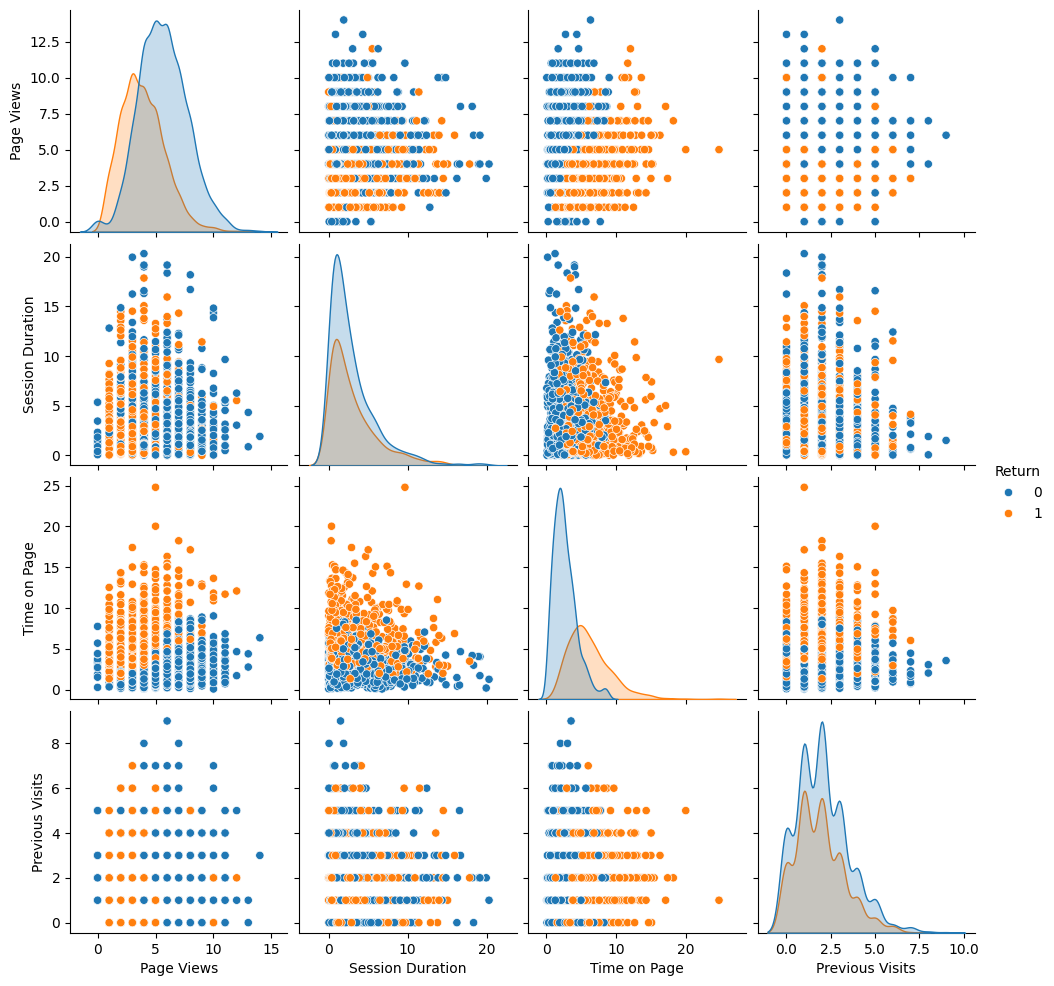

In [5]:
sns.pairplot(df,hue='Return')

In [6]:
#step1--split the data 
X = df.drop("Return", axis=1)
y = df["Return"]

In [69]:
# np.isinf(X).sum()

In [7]:
#step--train/test/split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

In [8]:
X_train.shape

(1600, 5)

In [9]:
y_train.shape

(1600,)

In [10]:


class IQRCapper(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        self.columns = X.columns  # column names save karo
        
        self.Q1 = X.quantile(0.25)
        self.Q3 = X.quantile(0.75)
        self.IQR = self.Q3 - self.Q1
        
        self.lower_bound = self.Q1 - 1.5 * self.IQR
        self.upper_bound = self.Q3 + 1.5 * self.IQR
        
        return self
    
    def transform(self, X):
        X_capped = X.copy()
        
        for col in self.columns:
            X_capped[col] = X_capped[col].clip(
                lower=self.lower_bound[col],
                upper=self.upper_bound[col]
            )
        
        return X_capped

In [10]:
X_train.head()

,Page Views,Session Duration,Traffic Source,Time on Page,Previous Visits
968,6,3.282703,Social,15.487085,2
240,3,9.721492,Paid,2.237548,1
819,2,2.464784,Organic,3.836196,1
692,10,1.664132,Paid,3.912895,2
420,5,10.455330,Paid,5.251470,1


In [11]:
numaric_cols = [0,1,3,4]  
categorical_cols = [2]

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('iqr', IQRCapper(), numaric_cols),
        ('log_transformer', FunctionTransformer(np.log1p),numaric_cols),
        ('ohe_Traffic_Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols )
    ]
)


In [ ]:
# trf_all = ColumnTransformer([
#     ('iqr', IQRCapper(), num_cols),
#     ('log_income', FunctionTransformer(np.log1p),numeric_cols),
#     ('Traffic_Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
# ], remainder='passthrough')

In [ ]:
# ('iqr', IQRCapper(), num_cols),trf2 = ColumnTransformer([
    
# ], remainder='passthrough')

In [ ]:
# trf3 = ColumnTransformer([
#     ('log_income', FunctionTransformer(np.log1p), [1,2,4,5,6]),   # column index 3 need improvement code correct but information wrong 
#     ('sqrt_age', FunctionTransformer(np.sqrt), [2])
# ], remainder='passthrough')

In [ ]:
# # one hot encoding
# trf4 = ColumnTransformer([
#     ('ohe_Traffic_Source',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[3])
# ],remainder='passthrough')

In [13]:
pipe = Pipeline([
    ('preprocessor', preprocessor)
])

In [14]:
X_train_transform = pipe.fit_transform(X_train)
X_test_transform = pipe.transform(X_test)

In [15]:
lr = LogisticRegression(max_iter=500, random_state=42)
    

### LogisticRegression algorithm

In [16]:
lr.fit(X_train_transform, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [17]:
y_pred = lr.predict(X_test_transform)

In [18]:
    # Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [19]:
# Print results
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print("Confusion Matrix:")
print(cm)

Accuracy : 0.8550
Precision: 0.8217
Recall   : 0.7518
F1-Score : 0.7852
Confusion Matrix:
[[236  23]
 [ 35 106]]


In [20]:
#predict test data 

y_test_pred = lr.predict(X_test_transform)

In [21]:
# Predict train data
y_train_pred = lr.predict(X_train_transform)

In [22]:

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.864375
Test Accuracy: 0.855


In [23]:
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}


In [24]:

cv_results = cross_validate(lr, X_train_transform, y_train, cv=5, scoring=scoring)

# Average results print
print("Logistic Regression 5-Fold CV Results:")
print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score : {cv_results['test_f1'].mean():.4f}")

Logistic Regression 5-Fold CV Results:
Accuracy : 0.8619
Precision: 0.8384
Recall   : 0.8155
F1-Score : 0.8262


In [25]:
dt= DecisionTreeClassifier(random_state=42)
rd= RandomForestClassifier(n_estimators=100, random_state=42)
gd= GradientBoostingClassifier(n_estimators=100, random_state=42)

### Decision Tree Algorithm

In [27]:
dt.fit(X_train_transform, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
y_pred_dt = dt.predict(X_test_transform)

In [29]:
accu = accuracy_score(y_test, y_pred_dt)
preci = precision_score(y_test, y_pred_dt)
reca = recall_score(y_test, y_pred_dt)
f1s = f1_score(y_test, y_pred_dt)
cme = confusion_matrix(y_test, y_pred_dt)

In [30]:
print(f"Accuracy : {accu:.4f}")
print(f"Precision: {preci:.4f}")
print(f"Recall   : {reca:.4f}")
print(f"F1-Score : {f1s:.4f}")
print("Confusion Matrix:")
print(cme)

Accuracy : 0.8275
Precision: 0.7609
Recall   : 0.7447
F1-Score : 0.7527
Confusion Matrix:
[[226  33]
 [ 36 105]]


### randomForestClassifier algorithm

In [31]:
rd.fit(X_train_transform, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred_rd = rd.predict(X_test_transform)

In [33]:
ac = accuracy_score(y_test, y_pred_rd)
pr = precision_score(y_test, y_pred_rd)
re = recall_score(y_test, y_pred_rd)
f = f1_score(y_test, y_pred_rd)
c = confusion_matrix(y_test, y_pred_rd)

In [34]:
print(f"Accuracy : {ac:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1-Score : {f:.4f}")
print("Confusion Matrix:")
print(c)

Accuracy : 0.8525
Precision: 0.8015
Recall   : 0.7730
F1-Score : 0.7870
Confusion Matrix:
[[232  27]
 [ 32 109]]


In [35]:
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}


In [36]:

cv_results = cross_validate(rd, X_train_transform, y_train, cv=5, scoring=scoring)

# Average results print
print("random Forest 5-Fold CV Results:")
print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score : {cv_results['test_f1'].mean():.4f}")

random Forest 5-Fold CV Results:
Accuracy : 0.8706
Precision: 0.8352
Recall   : 0.8481
F1-Score : 0.8411


### gradient boosting algorithm

In [26]:
gd.fit(X_train_transform, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [28]:
y_pred_gd = gd.predict(X_test_transform)

In [30]:
a = accuracy_score(y_test, y_pred_gd)
p= precision_score(y_test, y_pred_gd)
r = recall_score(y_test, y_pred_gd)
f1sco = f1_score(y_test, y_pred_gd)
cmat = confusion_matrix(y_test, y_pred_gd)

In [31]:
print(f"Accuracy : {a:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall   : {r:.4f}")
print(f"F1-Score : {f1sco:.4f}")
print("Confusion Matrix:")
print(cmat)

Accuracy : 0.8500
Precision: 0.7914
Recall   : 0.7801
F1-Score : 0.7857
Confusion Matrix:
[[230  29]
 [ 31 110]]


In [32]:
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

In [34]:

cv_results = cross_validate(gd, X_train_transform, y_train, cv=5, scoring=scoring)

# Average results print
print("gradient boosting 5-Fold CV Results:")
print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score : {cv_results['test_f1'].mean():.4f}")

gradient boosting 5-Fold CV Results:
Accuracy : 0.8725
Precision: 0.8451
Recall   : 0.8372
F1-Score : 0.8409
